# **Agrupamiento No Supervisado (Clustering)**
## ATUS Anual 2024
### Proyecto Final — Almacenes y Minería de Datos

**Objetivo.** Identificar perfiles de accidente a partir de sus condiciones de contexto, temporales, de zona, de tipo y causa, vehiculares y del conductor y después relacionar cada perfil con la severidad (`CLASACC`) para conectar el resultado con el modelo supervisado.

Toda la lógica vive en el paquete `src/clustering/`:

- `AccidentClusteringPreprocessor` (preparación de datos)
- `ClusteringStrategy` y sus subclases (patrón Strategy para los algoritmos)
- `ClusterAnalyzer` (orquestador de la exploración)
- `ClusteringModel` (artefacto para reutilizar el modelo). 


## 1. Configuración e importación

Se añade la carpeta `src/` al `path` para poder importar el paquete `clustering`. Todas las semillas
aleatorias se fijan en `RANDOM_STATE = 42` para garantizar la reproducibilidad de los resultados.


In [42]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Hace visible el paquete src/clustering desde la carpeta notebooks/
SRC_DIR = Path.cwd().parent / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from clustering import (
    ClusterAnalyzer,
    ClusteringModel,
    KMeansStrategy,
    AgglomerativeStrategy,
    DBSCANStrategy,
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

DATA_PATH = "../data/atus_anual_2024_limpio.csv"
CONFIG_PATH = "../src/config/repository_config.yaml"

print("Entorno listo. Semilla:", RANDOM_STATE)


Entorno listo. Semilla: 42


## 2. Carga de datos y selección de variables

El `ClusterAnalyzer` carga el dataset limpio a través del `DataRepository` y
prepara una muestra de 40,000 registros. La muestra se usa en los cálculos costosos
(índice de silueta, agrupamiento jerárquico y t-SNE), que son inviables sobre los 374,078 registros
completos. El modelo final, en cambio, se entrena sobre todo el dataset.

El preprocesador define explícitamente qué variables entran al agrupamiento y cuáles se excluyen.


In [43]:
from IPython.display import display

analyzer = ClusterAnalyzer(DATA_PATH, config_path=CONFIG_PATH, random_state=RANDOM_STATE)
analyzer.prepare(sample_size=40_000)

resumen_carga = pd.DataFrame([
    {"Parámetro": "Dataset completo",       "Valor": f"{analyzer.df_full.shape[0]:,} filas × {analyzer.df_full.shape[1]} columnas"},
    {"Parámetro": "Muestra de trabajo",     "Valor": f"{analyzer.df_sample.shape[0]:,} filas"},
    {"Parámetro": "Matriz preprocesada",    "Valor": f"{analyzer.matrix_sample.shape[0]:,} filas × {analyzer.matrix_sample.shape[1]} columnas"},
    {"Parámetro": "Semilla aleatoria",      "Valor": str(RANDOM_STATE)},
])
display(resumen_carga.style.hide(axis="index"))

Parámetro,Valor
Dataset completo,"374,078 filas × 42 columnas"
Muestra de trabajo,"40,000 filas"
Matriz preprocesada,"40,000 filas × 60 columnas"
Semilla aleatoria,42


In [44]:
from IPython.display import display
pre = analyzer.preprocessor

# Variables que entran al agrupamiento
variables_entrada = pd.DataFrame([
    {"Grupo": "Temporales",  "Variables": ", ".join(pre.temporal_features)},
    {"Grupo": "Zona",        "Variables": ", ".join(pre.zone_features)},
    {"Grupo": "Tipo y causa","Variables": ", ".join(pre.accident_features)},
    {"Grupo": "Vehiculares", "Variables": ", ".join(pre.vehicle_features)},
    {"Grupo": "Conductor (categóricas)", "Variables": ", ".join(pre.driver_categorical_features)},
    {"Grupo": "Conductor (numéricas)",   "Variables": ", ".join(pre.driver_numeric_features)},
])

# Variables excluidas
variables_excluidas = pd.DataFrame([
    {"Variable(s)": pre.TARGET_COLUMN,
     "Razón": "Variable objetivo del modelo supervisado"},
    {"Variable(s)": ", ".join(pre.VICTIM_COLUMNS),
     "Razón": "Determinan directamente CLASACC — fuga de información"},
    {"Variable(s)": ", ".join(pre.HIGH_CARDINALITY_COLUMNS),
     "Razón": "Alta cardinalidad (32 / 1,435 categorías)"},
    {"Variable(s)": ", ".join(pre.NOISE_COLUMNS),
     "Razón": "Granularidad temporal demasiado fina"},
])

print(f"Variables de entrada al agrupamiento — {len(pre.numeric_features)} numéricas · {len(pre.categorical_features)} categóricas")
display(variables_entrada.style.hide(axis="index"))

print("\nVariables excluidas")
display(variables_excluidas.style.hide(axis="index"))

Variables de entrada al agrupamiento — 18 numéricas · 9 categóricas


Grupo,Variables
Temporales,"MES, ID_HORA, DIASEMANA"
Zona,"URBANA, SUBURBANA"
Tipo y causa,"TIPACCID, CAUSAACCI, CAPAROD"
Vehiculares,"AUTOMOVIL, CAMPASAJ, MICROBUS, PASCAMION, OMNIBUS, TRANVIA, CAMIONETA, CAMION, TRACTOR, FERROCARRI, MOTOCICLET, BICICLETA, OTROVEHIC"
Conductor (categóricas),"SEXO, ALIENTO, CINTURON"
Conductor (numéricas),"ID_EDAD, CONDUCTOR_FUGADO, EDAD_DESCONOCIDA"



Variables excluidas


Variable(s),Razón
CLASACC,Variable objetivo del modelo supervisado
"CONDMUERTO, CONDHERIDO, PASAMUERTO, PASAHERIDO, PEATMUERTO, PEATHERIDO, CICLMUERTO, CICLHERIDO, OTROMUERTO, OTROHERIDO",Determinan directamente CLASACC — fuga de información
"NOM_ENT, NOM_MUN","Alta cardinalidad (32 / 1,435 categorías)"
"ID_MINUTO, ID_DIA",Granularidad temporal demasiado fina


### Justificación de la selección y el preprocesamiento

**Variables incluidas.** Se eligieron las que describen el *contexto* del accidente, no su desenlace:

- **Temporales** (`MES`, `ID_HORA`, `DIASEMANA`): cuándo ocurre el accidente.
- **Zona** (`URBANA`, `SUBURBANA`): dónde, según la clasificación urbana/suburbana del INEGI.
- **Tipo y causa** (`TIPACCID`, `CAUSAACCI`, `CAPAROD`): naturaleza del percance y la superficie.
- **Vehiculares** (13 columnas de conteo): qué vehículos participaron.
- **Conductor** (`SEXO`, `ALIENTO`, `CINTURON`, `ID_EDAD`, `CONDUCTOR_FUGADO`, `EDAD_DESCONOCIDA`).

**Variables excluidas:**

- **`CLASACC`** es la variable objetivo del modelo supervisado.
- **Columnas de víctimas** determinan directamente esa severidad, así que incluirlas haría que el agrupamiento simplemente recuperara la severidad en lugar de descubrir perfiles.
- **`NOM_ENT` / `NOM_MUN`** tienen cardinalidad muy alta (32 y 1 435 categorías respectivamente) y
  generarían cientos de columnas dispersas sin valor de perfil.
- **`ID_MINUTO` / `ID_DIA`** aportan granularidad temporal sin valor de perfil.

**Preprocesamiento** (`AccidentClusteringPreprocessor`):

- `ID_EDAD` tiene 96,222 nulos intencionales (fuga y edad desconocida). Se imputa por la mediana,
  y las banderas `CONDUCTOR_FUGADO` y `EDAD_DESCONOCIDA` preservan esa información.
- Las categóricas se codifican con **one-hot** (`handle_unknown="ignore"` para tolerar categorías
  nuevas al reutilizar el modelo).
- Todas las numéricas se **estandarizan** con `StandardScaler`, paso obligatorio para K-Means porque
  el algoritmo se basa en distancias euclidianas y es sensible a la escala.


## 3. Elección del número de grupos

Para K-Means es necesario fijar el número de grupos `k`. Se usan dos criterios complementarios:

- **Método del codo:** se busca el `k` a partir del cual añadir grupos deja de reducir
  apreciablemente la inercia (suma de distancias intra-cluster).
- **Coeficiente de silueta:** mide qué tan separados y compactos quedan los grupos; valores más altos
  son mejores.


In [45]:
k_range = range(2, 11)

elbow = analyzer.elbow_scores(k_range)
sil = analyzer.silhouette_scores(k_range)

resumen_k = elbow.merge(sil, on="k")
resumen_k


,k,inercia,silueta
0,2,806656.399325,0.192111
1,3,765157.690633,0.080013
2,4,721334.660010,0.103741
3,5,687205.262397,0.120441
4,6,649590.245018,0.145596
5,7,612341.663918,0.149165
6,8,565117.984131,0.138093
7,9,536051.181693,0.160200
8,10,498717.843974,0.182055


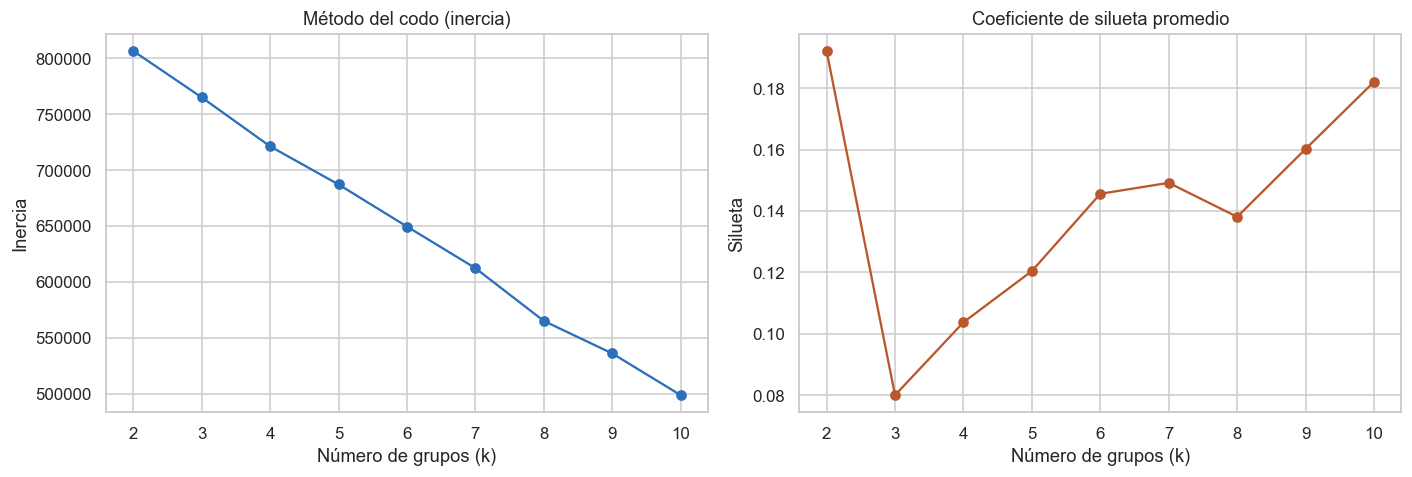

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(elbow["k"], elbow["inercia"], marker="o", color="#2c6fbb")
axes[0].set_title("Método del codo (inercia)")
axes[0].set_xlabel("Número de grupos (k)")
axes[0].set_ylabel("Inercia")

axes[1].plot(sil["k"], sil["silueta"], marker="o", color="#bb572c")
axes[1].set_title("Coeficiente de silueta promedio")
axes[1].set_xlabel("Número de grupos (k)")
axes[1].set_ylabel("Silueta")

plt.tight_layout()
plt.show()


### Elección de k = 4

- El **método del codo** muestra una inflexión leve alrededor de k = 4. En datasets de alta dimensionalidad la curva tiende a ser gradual, no tiene un codo nítido.
- La **silueta** es máxima en k = 2, pero se produce una partición trivial: motocicletas vs. todo lo demás. No aporta valor analítico, las motos son casos especiales.
- Se elige **k = 4** por el balance entre calidad métrica e interpretabilidad de los perfiles.

## 4. Comparación de algoritmos (Strategy)

El paquete implementa el patrón **Strategy**: cada algoritmo de agrupamiento es una clase con la misma
interfaz (`ClusteringStrategy`), de modo que el `ClusterAnalyzer` puede intercambiarlos sin cambiar su
código. Se comparan tres algoritmos sobre la misma muestra preprocesada:

- **K-Means**: eficiente, interpretable y permite asignar nuevos registros con `predict`; requiere definir `k`.
- **Aglomerativo (Ward)**: útil como referencia jerárquica, pero costoso en memoria para muchos registros.
- **DBSCAN**: detecta grupos por densidad y ruido, pero es sensible a sus parámetros y a la alta dimensionalidad.


In [47]:
K_ELEGIDO = 4

estrategias = [
    KMeansStrategy(n_clusters=K_ELEGIDO, random_state=RANDOM_STATE),
    AgglomerativeStrategy(n_clusters=K_ELEGIDO, linkage="ward"),
    DBSCANStrategy(eps=2.0, min_samples=15),
]

comparacion = analyzer.compare_strategies(estrategias)
comparacion


,algoritmo,n_grupos,n_ruido,silueta
0,K-Means (k=4),4,0,0.103741
1,"Aglomerativo (k=4, ward)",4,0,0.228182
2,"DBSCAN (eps=2.0, min_samples=15)",44,7636,0.185604


### Elección del algoritmo

Se elige **K-Means** como algoritmo principal por tres razones prácticas:

1. **Escalabilidad.** Es el único de los tres que entrena de forma eficiente sobre los 374,078
   registros completos; el aglomerativo es cuadrático en memoria y DBSCAN es muy sensible al tamaño.
2. **Reutilización.** K-Means produce un método `predict`, lo que permite asignar el
   perfil de accidentes nuevos sin re-entrenar. El
   aglomerativo y DBSCAN no ofrecen `predict` directo.
3. **Interpretabilidad.** Genera grupos de tamaño comparable y fáciles de describir mediante sus
   variables originales.

El agrupamiento aglomerativo y DBSCAN se conservan como contraste, pero no se usan como modelo final por las limitaciones.


## 5. Reducción de dimensionalidad (PCA)

Tras la codificación one-hot, el espacio de trabajo tiene muchas dimensiones. Se aplica **PCA** para revisar cuánta varianza concentran las primeras componentes y proyectar los grupos
a 2D para poder visualizarlos.


In [48]:
varianza = analyzer.pca_explained_variance(n_components=10)
# columnas reales: 'componente', 'varianza', 'varianza_acumulada'
display(
    varianza.style
    .format({"varianza": "{:.2%}", "varianza_acumulada": "{:.2%}"})
    .hide(axis="index")
    .bar(subset=["varianza"],           color="#2c6fbb", vmin=0)
    .bar(subset=["varianza_acumulada"], color="#fdae6b", vmin=0, vmax=1)
)

componente,varianza,varianza_acumulada
1,7.49%,7.49%
2,6.63%,14.12%
3,6.30%,20.41%
4,5.06%,25.47%
5,5.01%,30.48%
6,4.92%,35.40%
7,4.83%,40.23%
8,4.76%,44.99%
9,4.73%,49.72%
10,4.68%,54.40%


## 6. Modelo final K-Means y visualización de los grupos

Se ajusta el K-Means con el `k` elegido sobre la muestra y se proyectan los puntos con PCA y t-SNE,
coloreados por grupo. Estas proyecciones son solo para visualización: el agrupamiento se realiza en el
espacio completo estandarizado.


In [49]:
kmeans_final = KMeansStrategy(n_clusters=K_ELEGIDO, random_state=RANDOM_STATE)
etiquetas = analyzer.fit_strategy(kmeans_final)

# cluster_sizes devuelve DataFrame con columnas: 'n', 'porcentaje' (índice = cluster id)
tamanos = analyzer.cluster_sizes(etiquetas).reset_index()
tamanos.columns = ["Cluster", "Registros", "% de la muestra"]

display(
    tamanos.style
    .hide(axis="index")
    .format({"Registros": "{:,}", "% de la muestra": "{:.2f}%"})
    .bar(subset=["% de la muestra"], color="#2c6fbb", vmin=0, vmax=100)
)

Cluster,Registros,% de la muestra
0,"3,799",9.50%
1,"7,849",19.62%
2,"15,950",39.88%
3,"12,402",31.00%


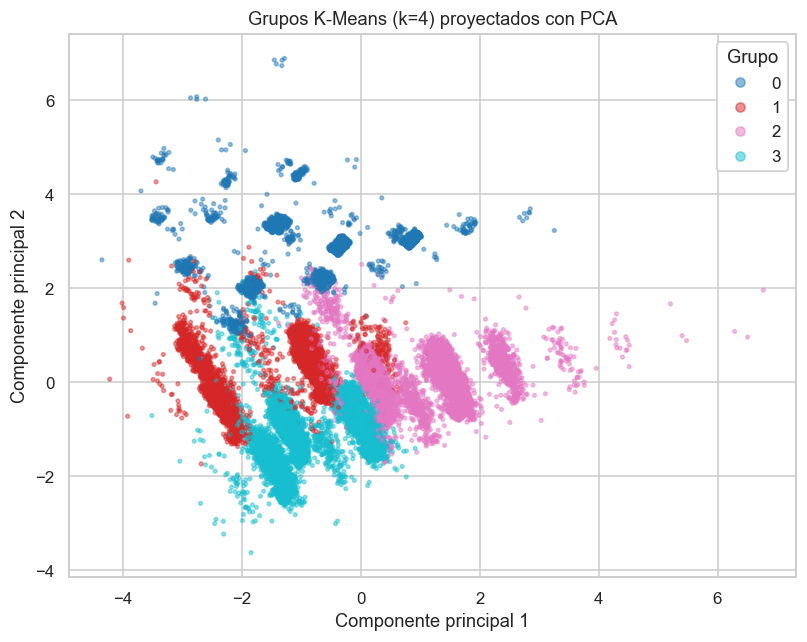

In [50]:
# Proyección PCA en 2D coloreada por grupo
coords_pca = analyzer.reduce_pca(n_components=2)

fig, ax = plt.subplots(figsize=(7.5, 6))
scatter = ax.scatter(
    coords_pca[:, 0], coords_pca[:, 1],
    c=etiquetas, cmap="tab10", s=6, alpha=0.45,
)
ax.set_title(f"Grupos K-Means (k={K_ELEGIDO}) proyectados con PCA")
ax.set_xlabel("Componente principal 1")
ax.set_ylabel("Componente principal 2")
legend = ax.legend(*scatter.legend_elements(), title="Grupo", loc="best")
ax.add_artist(legend)
plt.tight_layout()
plt.show()


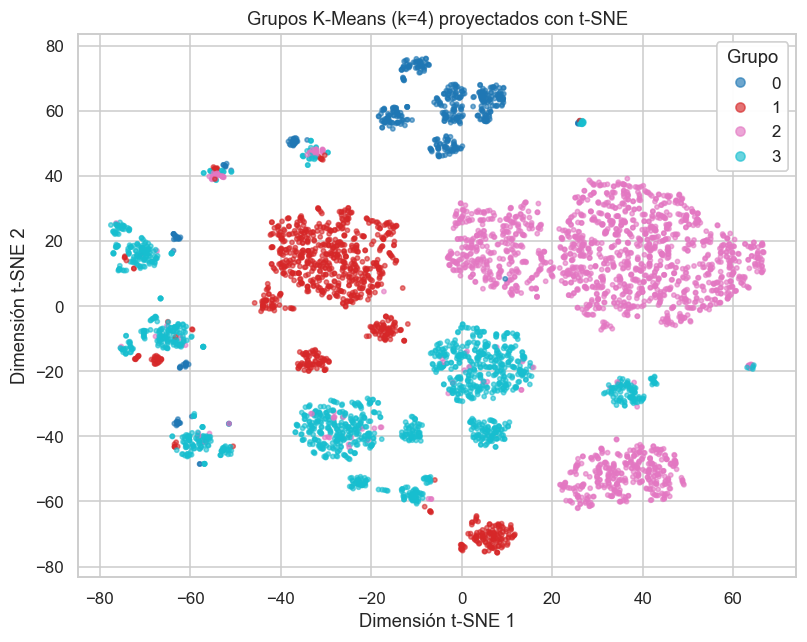

In [51]:
# Proyección t-SNE sobre una submuestra; colorea por grupo
coords_tsne, idx_tsne = analyzer.reduce_tsne(sample_size=5_000, perplexity=30.0)

fig, ax = plt.subplots(figsize=(7.5, 6))
scatter = ax.scatter(
    coords_tsne[:, 0], coords_tsne[:, 1],
    c=etiquetas[idx_tsne], cmap="tab10", s=8, alpha=0.6,
)
ax.set_title(f"Grupos K-Means (k={K_ELEGIDO}) proyectados con t-SNE")
ax.set_xlabel("Dimensión t-SNE 1")
ax.set_ylabel("Dimensión t-SNE 2")
legend = ax.legend(*scatter.legend_elements(), title="Grupo", loc="best")
ax.add_artist(legend)
plt.tight_layout()
plt.show()


## 7. Perfilado e interpretación de los grupos

Para que los grupos tengan significado, se describen con las variables originales. Se revisa la categoría dominante de las variables cualitativas clave, los promedios
de las variables numéricas y su relación con la severidad `CLASACC`.


In [52]:
from IPython.display import display, HTML

# profile_categorical devuelve DataFrame con índice 'cluster' y
# columnas: 'categoria_dominante' (str), 'proporcion' (float)
for col in ["TIPACCID", "CAUSAACCI", "URBANA", "SUBURBANA", "SEXO", "ALIENTO", "DIASEMANA"]:
    perfil = analyzer.profile_categorical(etiquetas, col).reset_index()
    display(HTML(f"<h4 style='margin-bottom:4px; margin-top:14px'>{col}</h4>"))
    display(
        perfil.style
        .hide(axis="index")
        .format({"proporcion": "{:.1%}"})
    )

cluster,categoria_dominante,proporcion
0,Colisión con vehículo automotor,44.1%
1,Colisión con motocicleta,77.2%
2,Colisión con vehículo automotor,75.9%
3,Colisión con vehículo automotor,80.5%


cluster,categoria_dominante,proporcion
0,Conductor,96.2%
1,Conductor,95.6%
2,Conductor,96.5%
3,Conductor,96.1%


cluster,categoria_dominante,proporcion
0,Accidente en intersección,63.0%
1,Accidente en intersección,63.5%
2,Accidente en intersección,70.8%
3,Accidente en intersección,72.3%


cluster,categoria_dominante,proporcion
0,Sin accidente en esta zona,88.4%
1,Sin accidente en esta zona,91.2%
2,Sin accidente en esta zona,93.4%
3,Sin accidente en esta zona,92.1%


cluster,categoria_dominante,proporcion
0,Desconocido,99.9%
1,Hombre,86.1%
2,Hombre,78.7%
3,Hombre,82.8%


cluster,categoria_dominante,proporcion
0,Se ignora,100.0%
1,No,66.3%
2,No,67.6%
3,No,76.1%


cluster,categoria_dominante,proporcion
0,Domingo,21.3%
1,Sabado,16.0%
2,Sabado,16.1%
3,Viernes,15.4%


In [53]:
# Promedios de variables numéricas seleccionadas por grupo
cols_num = ["ID_HORA", "MES", "ID_EDAD", "CONDUCTOR_FUGADO",
            "AUTOMOVIL", "MOTOCICLET", "CAMIONETA", "BICICLETA"]
perfil_num = analyzer.profile_numeric(etiquetas, cols_num)
perfil_num


,ID_HORA,MES,ID_EDAD,CONDUCTOR_FUGADO,AUTOMOVIL,MOTOCICLET,CAMIONETA,BICICLETA
cluster,,,,,,,,
0,12.681,6.585,61.000,0.999,1.056,0.200,0.121,0.014
1,14.029,6.578,34.330,0.000,0.755,1.072,0.069,0.014
2,12.977,6.507,38.324,0.000,1.816,0.002,0.007,0.015
3,13.413,6.569,39.430,0.000,0.623,0.001,0.357,0.008


## 8. Conexión con la severidad (`CLASACC`)

Aunque `CLASACC` no participó en la formación de los grupos, se puede cruzar cada perfil con la
severidad real para ver si algún perfil concentra más accidentes graves.


CLASACC,Sólo daños,No fatal,Fatal
row_0,,,
0,82.0%,15.8%,2.1%
1,55.2%,42.8%,2.0%
2,88.3%,10.9%,0.8%
3,90.4%,8.9%,0.7%


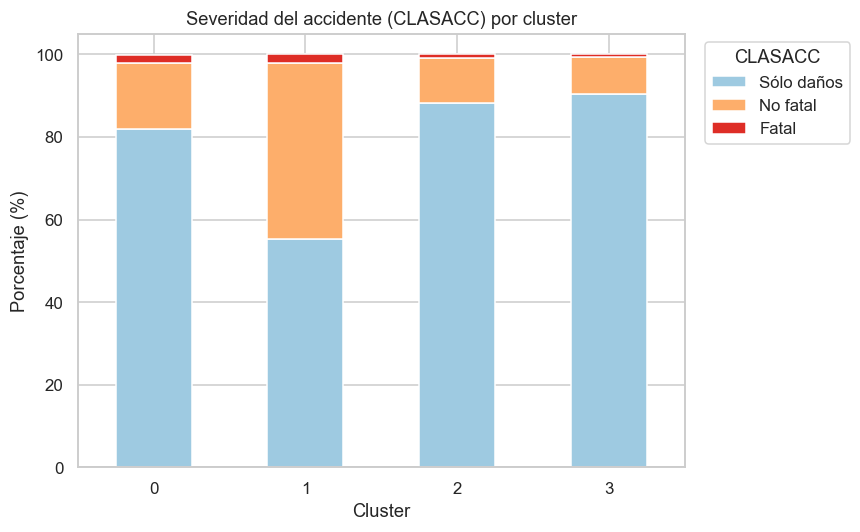

In [54]:
cruce = analyzer.crosstab_with_target(etiquetas, target="CLASACC", normalize="index")
# Reordenar columnas de menor a mayor severidad (lo que exista en los datos)
orden_severidad = ["Sólo daños", "No fatal", "Fatal"]
cruce = cruce[[c for c in orden_severidad if c in cruce.columns]]

display(
    cruce.style
    .format("{:.1%}")
    .background_gradient(subset=["Fatal"],      cmap="Reds",    vmin=0, vmax=0.05)
    .background_gradient(subset=["No fatal"],   cmap="Oranges", vmin=0, vmax=0.5)
    .background_gradient(subset=["Sólo daños"], cmap="Blues",   vmin=0, vmax=1)
    .set_caption("Distribución de severidad (CLASACC) por cluster")
)

ax = (cruce * 100).plot(kind="bar", stacked=True, figsize=(8, 5),
                        color=["#9ecae1", "#fdae6b", "#de2d26"])
ax.set_title("Severidad del accidente (CLASACC) por cluster")
ax.set_xlabel("Cluster")
ax.set_ylabel("Porcentaje (%)")
ax.legend(title="CLASACC", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Etiquetas interpretativas de los grupos

_Esta sección asigna un nombre a cada grupo a partir de los perfiles observados arriba. Las etiquetas
se completan tras ejecutar el notebook (ver el diccionario `etiquetas_clusters` en la siguiente celda)._


In [55]:
# Los cuatro perfiles y sus firmas identificadoras.
# La asignación automática de IDs ocurre en la sección 9 (entrenamiento),
# usando los labels del modelo completo.
perfiles_esperados = pd.DataFrame([
    {"Perfil": "Conductor fugado, accidente mixto", "Firma clave": "CONDUCTOR_FUGADO ≈ 1.0"},
    {"Perfil": "Accidente con motocicleta",         "Firma clave": "MOTOCICLET máximo del grupo"},
    {"Perfil": "Colisión con camioneta",            "Firma clave": "CAMIONETA máxima (excl. motos y fugados)"},
    {"Perfil": "Colisión multi-automóvil",          "Firma clave": "AUTOMOVIL ≈ 1.8 promedio"},
])
display(perfiles_esperados.style.hide(axis="index"))

Cluster ID,Perfil interpretativo
0,"Conductor fugado, accidente mixto"
1,Accidente con motocicleta
2,Colisión multi-automóvil
3,Colisión con camioneta


## 9. Entrenamiento del modelo final

El modelo final (`ClusteringModel`) se entrena sobre el **dataset completo** (374,078 registros) y se
guarda con `joblib` en `models/`. El objeto guardado contiene el preprocesador ajustado y el K-Means
entrenado, de modo que puede recargarse para asignar el perfil de accidentes nuevos.


In [58]:
# Entrenamiento sobre el dataset completo
modelo = ClusteringModel.train(
    analyzer.df_full, n_clusters=K_ELEGIDO, random_state=RANDOM_STATE
)

# Auto-asignación de etiquetas desde el modelo final
cols_firma = ["CONDUCTOR_FUGADO", "MOTOCICLET", "CAMIONETA", "AUTOMOVIL"]
cols_firma = [c for c in cols_firma if c in analyzer.df_full.columns]

labels_full  = modelo.strategy.estimator_.labels_
medias_full  = (
    analyzer.df_full[cols_firma]
    .assign(cluster=labels_full)
    .groupby("cluster")[cols_firma]
    .mean()
)

id_fugado_f    = int(medias_full["CONDUCTOR_FUGADO"].idxmax())
id_moto_f      = int(medias_full["MOTOCICLET"].idxmax())
restantes_f    = [c for c in medias_full.index if c not in (id_fugado_f, id_moto_f)]
id_camioneta_f = int(medias_full.loc[restantes_f, "CAMIONETA"].idxmax())
id_auto_f      = [c for c in medias_full.index if c not in (id_fugado_f, id_moto_f, id_camioneta_f)][0]

etiquetas_clusters = {
    id_fugado_f:    "Conductor fugado, accidente mixto",
    id_moto_f:      "Accidente con motocicleta",
    id_camioneta_f: "Colisión con camioneta",
    id_auto_f:      "Colisión multi-automóvil",
}
modelo.set_cluster_labels(etiquetas_clusters)

# Guardar
RUTA_MODELO = "../models/clustering_kmeans.joblib"
modelo.save(RUTA_MODELO)

# Resumen
resumen_modelo = pd.DataFrame([
    {"Parámetro": "Registros de entrenamiento", "Valor": f"{analyzer.df_full.shape[0]:,}"},
    {"Parámetro": "Número de grupos (k)",        "Valor": str(modelo.n_clusters)},
    {"Parámetro": "Ruta del modelo guardado",    "Valor": RUTA_MODELO},
    {"Parámetro": "Contenido del archivo",       "Valor": "ColumnTransformer ajustado + KMeans entrenado"},
    {"Parámetro": "Etiquetas asignadas",          "Valor": str(etiquetas_clusters)},
])
display(resumen_modelo.style.hide(axis="index"))

Parámetro,Valor
Registros de entrenamiento,"374,078"
Número de grupos (k),4
Ruta del modelo guardado,../models/clustering_kmeans.joblib
Contenido del archivo,ColumnTransformer ajustado + KMeans entrenado
Etiquetas asignadas,"{0: 'Conductor fugado, accidente mixto', 2: 'Accidente con motocicleta', 1: 'Colisión con camioneta', 3: 'Colisión multi-automóvil'}"


### Demostración de recarga

La siguiente celda simula el escenario: se recarga el modelo desde disco y se usa para asignar el perfil de unos accidentes nuevos.


In [59]:
# Recarga desde disco (sin reutilizar el objeto 'modelo')
modelo_recargado = ClusteringModel.load(RUTA_MODELO)

# Toma 5 accidentes nuevos del dataset y les asigna su perfil
nuevos = analyzer.df_full.sample(n=5, random_state=7).reset_index(drop=True)
ids_predichos = modelo_recargado.predict(nuevos)
nombres_predichos = modelo_recargado.predict_labels(nuevos)

resultado = nuevos[["TIPACCID", "URBANA", "ID_HORA", "SEXO", "CLASACC"]].copy()
resultado["cluster_id"] = ids_predichos
resultado["perfil"] = nombres_predichos
resultado


,TIPACCID,URBANA,ID_HORA,SEXO,CLASACC,cluster_id,perfil
0,Colisión con vehículo automotor,Accidente en intersección,22,Desconocido,No fatal,0,"Conductor fugado, accidente mixto"
1,Colisión con vehículo automotor,Sin accidente en esta zona,11,Hombre,Sólo daños,3,Colisión multi-automóvil
2,Colisión con vehículo automotor,Accidente en intersección,6,Hombre,No fatal,3,Colisión multi-automóvil
3,Colisión con objeto fijo,Sin accidente en esta zona,18,Hombre,Sólo daños,3,Colisión multi-automóvil
4,Colisión con motocicleta,Accidente en no intersección,13,Hombre,Sólo daños,2,Accidente con motocicleta


## Perfiles del modelo final (k = 4, 374,078 registros)

| Cluster | Registros | % | Descripción | Rasgos clave |
|---------|----------:|--:|-------------|--------------|
| **0** | 34,944 | 9.3% | Conductor fugado, accidente mixto | 99.9% `CONDUCTOR_FUGADO=1`; Fatal 2.2% |
| **1** | 116,665 | 31.2% | Colisión con camioneta | `CAMIONETA` 0.35 prom.; Sólo daños 90.7% |
| **2** | 76,057 | 20.3% | Accidente con motocicleta | `MOTOCICLET` 1.03 prom., conductor 34 años; No fatal 43.2% |
| **3** | 146,412 | 39.1% | Colisión multi-automóvil | `AUTOMOVIL` 1.83 prom.; Sólo daños 88.8% |

### Validación

El **Cluster 2 (motocicletas)** concentra el **43.2% de accidentes con heridos** (`No fatal`),
aunque `CLASACC` y las columnas de víctimas nunca entraron al modelo. El agrupamiento descubrió
la vulnerabilidad de los motociclistas de forma descriptiva, a partir del contexto del
accidente.

### Limitaciones

- La silueta global (0.104) es modesta, esperada en espacios de alta dimensionalidad.
- Los IDs de cluster de la exploración en muestra y del modelo final pueden no coincidir entre sí;
  la correspondencia se establece por el perfil semántico de cada grupo, no por el número asignado.
